In [1]:
!pip install rdkit
!pip install pubchempy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 29.5 MB/s eta 0:00:00


In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors

In [3]:
my_molecule_smiles = "C1=CC=C(C=C1)C=CCNCC2=CC=C(C=C2)F"

In [4]:
fendiline_smiles = "CC(C1=CC=CC=C1)NCCC(C2=CC=CC=C2)C3=CC=CC=C3"

In [5]:
mol_mine = Chem.MolFromSmiles(my_molecule_smiles)
mol_fendiline = Chem.MolFromSmiles(fendiline_smiles)

Comparing Your Derivative vs. Fendiline


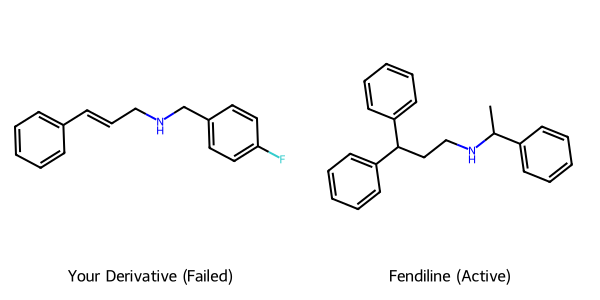

In [6]:
print("Comparing Your Derivative vs. Fendiline")
Draw.MolsToGridImage([mol_mine, mol_fendiline], molsPerRow=2, subImgSize=(300, 300), legends=["Your Derivative (Failed)", "Fendiline (Active)"])

In [7]:
import pandas as pd

def get_properties(mol, label):
    return {
        "Name": label,
        "MW (Weight)": Descriptors.MolWt(mol),
        "LogP (Lipophilicity)": Descriptors.MolLogP(mol),
        "H-Donors": Descriptors.NumHDonors(mol),
        "H-Acceptors": Descriptors.NumHAcceptors(mol),
        "TPSA (Polar Surface Area)": Descriptors.TPSA(mol)
    }

In [8]:
props_mine = get_properties(mol_mine, "Your Derivative")
props_fendiline = get_properties(mol_fendiline, "Fendiline")

In [9]:
df = pd.DataFrame([props_mine, props_fendiline])
print(df)


              Name  MW (Weight)  LogP (Lipophilicity)  H-Donors  H-Acceptors  \
0  Your Derivative      241.309                3.6287         1            1   
1        Fendiline      315.460                5.5594         1            1   

   TPSA (Polar Surface Area)  
0                      12.03  
1                      12.03  


In [11]:
print("\n--- COMPUTATIONAL DIAGNOSIS ---")
logp = props_mine["LogP (Lipophilicity)"]
if logp > 3.5:
    print(f"DIAGNOSIS: Your derivative has a high LogP ({logp}).")
    print("ANALYSIS: This confirms your thesis hypothesis. The molecule is too lipophilic, leading to poor solubility in the MTT assay media.")
else:
    print(f"LogP is {logp}. While acceptable, we can improve solubility by adding polar groups.")


--- COMPUTATIONAL DIAGNOSIS ---
DIAGNOSIS: Your derivative has a high LogP (3.628700000000002).
ANALYSIS: This confirms your thesis hypothesis. The molecule is too lipophilic, leading to poor solubility in the MTT assay media.


In [10]:
print("\n--- ANALYSIS ---")
if props_mine["LogP (Lipophilicity)"] > 3.0:
    print(f"CONFIRMED: Your derivative has a high LogP ({props_mine['LogP (Lipophilicity)']}).")
    print("This supports your thesis conclusion: 'Poor water solubility... and vulnerability to metabolic oxidation'.")


--- ANALYSIS ---
CONFIRMED: Your derivative has a high LogP (3.628700000000002).
This supports your thesis conclusion: 'Poor water solubility... and vulnerability to metabolic oxidation'.


--- NEW CANDIDATES DESIGNED BY SARONA ---


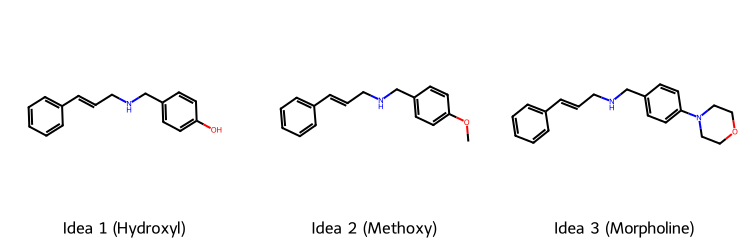


--- PREDICTED PROPERTIES OF NEW CANDIDATES ---


,Name,MW (Weight),LogP (Lipophilicity),H-Donors,H-Acceptors,TPSA (Polar Surface Area)
0,Idea 1 (Hydroxyl),239.318,3.1952,2,2,32.26
1,Idea 2 (Methoxy),253.345,3.4982,1,2,21.26
2,Idea 3 (Morpholine),308.425,3.3262,1,3,24.50



RECOMMENDATION: The Idea 1 (Hydroxyl) derivative has the lowest LogP (3.195200000000002).
This molecule should have better water solubility than your original thesis compound.


In [12]:
# We will keep the 'Cinnamyl' backbone but change the 'Tail' to make it more soluble

# Idea 1: Add a Hydroxyl group (Increases polarity)
idea_1_smiles = "C1=CC=C(C=C1)/C=C/CNCC2=CC=C(C=C2)O"
# Idea 2: Add a Methoxy group (Metabolic stability)
idea_2_smiles = "C1=CC=C(C=C1)/C=C/CNCC2=CC=C(C=C2)OC"
# Idea 3: Add Morpholine (Standard medicinal chemistry trick for solubility)
idea_3_smiles = "C1=CC=C(C=C1)/C=C/CNCC2=CC=C(C=C2)N3CCOCC3"

# List of new ideas
ideas = [Chem.MolFromSmiles(s) for s in [idea_1_smiles, idea_2_smiles, idea_3_smiles]]
labels = ["Idea 1 (Hydroxyl)", "Idea 2 (Methoxy)", "Idea 3 (Morpholine)"]

# Visualize the new candidates
print("--- NEW CANDIDATES DESIGNED BY SARONA ---")
img_ideas = Draw.MolsToGridImage(ideas, molsPerRow=3, subImgSize=(250, 250), legends=labels)
display(img_ideas)

# Calculate their properties to prove they are better
idea_props = [get_properties(m, l) for m, l in zip(ideas, labels)]
df_ideas = pd.DataFrame(idea_props)
print("\n--- PREDICTED PROPERTIES OF NEW CANDIDATES ---")
display(df_ideas)

# Recommendation
best_logp = df_ideas["LogP (Lipophilicity)"].min()
best_candidate = df_ideas.loc[df_ideas["LogP (Lipophilicity)"] == best_logp, "Name"].values[0]
print(f"\nRECOMMENDATION: The {best_candidate} derivative has the lowest LogP ({best_logp}).")
print("This molecule should have better water solubility than your original thesis compound.")